### Análisis Exploratorio, Comparativo y Contraste de Hipótesis

In [2]:
import pandas as pd
import numpy as np

pd.options.mode.copy_on_write = True # CoW por defecto a partir de Pandas 3.0.0

import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
# Carga de datasets limpios
# se desactiva low_memory para evitar warnings por tipos mixtos)

licencias = pd.read_csv(
    "../../Datasets/Licencias_2024y2025_limpio.csv",
    parse_dates=["fechanacimiento", "fechaaltasolicitud"],
    low_memory=False
)


In [4]:
siniestros = pd.read_csv(
    "../../Datasets/siniestros_limpio.csv",
    parse_dates=["fechaparteaccidente", "fechaaltaparte"],
    low_memory=False
)


In [5]:
licencias.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18915 entries, 0 to 18914
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   nif                            18915 non-null  object        
 1   sexo                           18915 non-null  object        
 2   fechanacimiento                18915 non-null  datetime64[ns]
 3   descripcionprovinciadomicilio  18915 non-null  object        
 4   fechaaltasolicitud             18915 non-null  datetime64[ns]
 5   temporada                      18915 non-null  int64         
 6   modalidad                      18915 non-null  object        
 7   categoria                      18915 non-null  object        
 8   complementos                   5080 non-null   object        
 9   importecomplemento             18915 non-null  int64         
 10  importefmm                     18915 non-null  float64       
 11  importeseguro  

In [6]:
siniestros.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   nif                  631 non-null    object        
 1   fechaparteaccidente  631 non-null    datetime64[ns]
 2   fechaaltaparte       631 non-null    datetime64[ns]
 3   codigo               631 non-null    int64         
 4   actividad            631 non-null    object        
 5   lugar                631 non-null    object        
 6   fecharecepcion       631 non-null    object        
 7   entrenamiento        631 non-null    bool          
 8   actividadpersonal    631 non-null    bool          
 9   actividadorganizada  631 non-null    bool          
 10  festivo              631 non-null    bool          
 11  nresponsables        631 non-null    int64         
 12  tamañogrupo          631 non-null    int64         
 13  descripciongrado     631 non-null  

### Creación del dataset analítico

In [7]:
df_analisis = siniestros.merge(
    licencias[
        [
            "nif",
            "modalidad",   # ← tipo de seguro
            "sexo",
            "edad",
            "categoria",
            "temporada"
        ]
    ],
    on="nif",
    how="left"
)


In [8]:
df_analisis.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   nif                  631 non-null    object        
 1   fechaparteaccidente  631 non-null    datetime64[ns]
 2   fechaaltaparte       631 non-null    datetime64[ns]
 3   codigo               631 non-null    int64         
 4   actividad            631 non-null    object        
 5   lugar                631 non-null    object        
 6   fecharecepcion       631 non-null    object        
 7   entrenamiento        631 non-null    bool          
 8   actividadpersonal    631 non-null    bool          
 9   actividadorganizada  631 non-null    bool          
 10  festivo              631 non-null    bool          
 11  nresponsables        631 non-null    int64         
 12  tamañogrupo          631 non-null    int64         
 13  descripciongrado     631 non-null  

In [9]:
df_analisis.head()

,nif,fechaparteaccidente,fechaaltaparte,codigo,actividad,lugar,fecharecepcion,entrenamiento,actividadpersonal,actividadorganizada,...,tamañogrupo,descripciongrado,pais,provincia,tipoaccidente,modalidad,sexo,edad,categoria,temporada
0,05277296S,2024-01-01 00:00:00,2024-01-02 12:04:00,745025061,ESQUÍ ALPINO,BAQUEIRA BERET,2024-01-02 00:00:00,False,True,False,...,0,LEVE,ESPAÑA,LLEIDA,TROPIEZOS (CAÍDA AL MISMO NIVEL),B,FEMENINO,55,Mayor Mujer,2024
1,50775542Y,2024-01-01 14:00:00,2024-01-02 10:48:00,745024991,BTT,EL PARDO,2024-01-02 10:48:00,True,False,False,...,0,NAN,ESPAÑA,MADRID,OTRO: GOLPE EN EL PIE,B,MASCULINO,33,Mayor Varón,2024
2,11851622K,2024-01-02 17:00:00,2024-01-18 09:27:00,745038371,BTT,CARRETERA DE LA REPUBLICA - DEHESAS DE CERCEDILLA,2024-01-18 00:00:00,False,True,False,...,0,LEVE,ESPAÑA,MADRID,TROPIEZOS (CAÍDA AL MISMO NIVEL),B,FEMENINO,39,Mayor Mujer,2024
3,50208024J,2024-01-04 00:00:00,2024-01-15 16:09:00,745034561,CARRERAS POR MONTAÑA,LA PEDRIZA,2024-01-15 00:00:00,True,False,False,...,1,LEVE,ESPAÑA,MADRID,COLISIÓN CON ROCAS,B,MASCULINO,47,Mayor Varón,2024
4,09141804V,2024-01-04 19:30:00,2024-01-04 23:32:00,745025901,ROCÓDROMO,ROCÓDROMO INDOORWALL,2024-01-04 23:32:00,True,False,False,...,9,NAN,ESPAÑA,MADRID,OTRO: CORTE CON EL FILO DEL CRAMPÓN,C,MASCULINO,19,Mayor Varón,2024


### Limpieza analítica focalizada


In [10]:
# Eliminación de nulos SOLO en variables clave

df_analisis = df_analisis.dropna(
    subset=["modalidad", "descripciongrado"]
)


In [11]:
df_analisis.isnull().sum()


nif                    0
fechaparteaccidente    0
fechaaltaparte         0
codigo                 0
actividad              0
lugar                  0
fecharecepcion         0
entrenamiento          0
actividadpersonal      0
actividadorganizada    0
festivo                0
nresponsables          0
tamañogrupo            0
descripciongrado       0
pais                   0
provincia              0
tipoaccidente          0
modalidad              0
sexo                   0
edad                   0
categoria              0
temporada              0
dtype: int64

### Tratamiento de valores nulos en el dataset analítico

La eliminación de valores nulos se realizó de forma selectiva, atendiendo
exclusivamente a las variables directamente implicadas en las hipótesis
planteadas.

En concreto, se eliminaron únicamente los registros con valores nulos en:

- `modalidad`, variable explicativa principal (tipo de seguro).
- `descripciongrado`, variable respuesta que mide la gravedad del accidente.

Esta decisión se adopta para garantizar la validez del análisis comparativo
y de los contrastes estadísticos, evitando al mismo tiempo una pérdida
innecesaria de información en variables no críticas para los objetivos
del estudio.

Los valores nulos en otras variables se conservaron al no interferir
en la respuesta a la pregunta de investigación.


## Hipótesis del estudio

A partir del contexto del proyecto y de los objetivos planteados, se formulan las siguientes hipótesis a contrastar durante el análisis exploratorio de datos:

**Hipótesis A**  
Los federados con seguros de mayor cobertura presentan una tasa de siniestros superior al promedio del total de federados.

**Hipótesis B**  
Los federados mayores de 35 años tienen siniestros de mayor gravedad media que los asociados a seguros básicos.

Estas hipótesis sirven como base para orientar el análisis descriptivo, comparativo y el posterior contraste estadístico.


### Análisis UNIVARIANTE

#### Distribución de gravedad del siniestro

Se analiza la distribución de la variable `descripciongrado` para identificar la frecuencia de siniestros leves, graves y mortales, proporcionando una primera visión del perfil general de la siniestralidad.


In [12]:
df_analisis["descripciongrado"].value_counts(dropna=False)


descripciongrado
LEVE      526
GRAVE      57
NAN        42
MORTAL      6
Name: count, dtype: int64

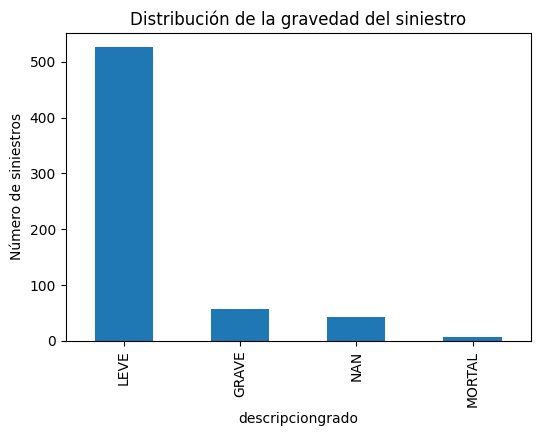

In [13]:
df_analisis["descripciongrado"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Distribución de la gravedad del siniestro"
)
plt.ylabel("Número de siniestros")
plt.show()



Análisis de la gravedad de los siniestros

La distribución de la gravedad de los siniestros muestra un claro predominio de los accidentes leves, que representan la gran mayoría de los casos registrados en el dataset.

Los accidentes graves constituyen una proporción significativamente menor, mientras que los accidentes mortales son muy poco frecuentes. La categoría NAN corresponde a registros en los que no se dispone de información sobre el grado de gravedad del siniestro.

Esta distribución indica que, aunque la ocurrencia de siniestros es elevada, la mayor parte de ellos no presenta consecuencias de alta gravedad, si bien la presencia de valores sin clasificar debe tenerse en cuenta en los análisis posteriores.



### Tasa global de siniestralidad

Se calcula la tasa global de siniestralidad como el número total de siniestros registrados dividido entre el número total de federados únicos, expresado por cada 1.000 federados.

Este indicador permite obtener una visión general del nivel de riesgo del colectivo analizado y sirve como referencia base para comparar posteriormente la siniestralidad por modalidad, edad u otros factores.


In [14]:
# Cálculo de la tasa de siniestralidad

num_siniestros = siniestros.shape[0]
num_federados = licencias["nif"].nunique()

tasa_siniestralidad = (num_siniestros / num_federados) * 1000

tasa_siniestralidad

33.36153114095379

La tasa global de siniestralidad es de aproximadamente 33 siniestros por cada 1.000 federados, lo que nos proporciona un punto de referencia general antes de analizar diferencias entre perfiles.

### Indicadores globales del estudio

En la siguiente tabla se presentan los principales indicadores agregados del estudio, que resumen el volumen total de federados analizados, el número de siniestros registrados y la tasa global de siniestralidad expresada por cada 1.000 federados.

Estos indicadores permiten contextualizar el nivel general de riesgo del colectivo y sirven como punto de partida para los análisis posteriores por modalidad, edad y gravedad del siniestro.


In [15]:
cuadro_global = pd.DataFrame({
    "Indicador": [
        "Número de federados",
        "Número de siniestros",
        "Tasa de siniestralidad (por 1.000)"
    ],
    "Valor": [
        num_federados,
        num_siniestros,
        round(tasa_siniestralidad, 2)
    ]
})

cuadro_global

,Indicador,Valor
0,Número de federados,18914.00
1,Número de siniestros,631.00
2,Tasa de siniestralidad (por 1.000),33.36


A nivel global, el estudio analiza cerca de 19.000 federados, con 631 siniestros registrados, lo que supone una tasa de siniestralidad de 33,36 por cada 1.000 federados.

## Distribución por modalidad de seguro
Se estudia la distribución de los siniestros según la modalidad del seguro contratado, con el objetivo de identificar qué tipos de seguro concentran un mayor número de accidentes.


In [16]:
df_analisis["modalidad"].value_counts()


modalidad
B     481
C      95
D      26
A      16
AU      5
B6      4
A6      3
OT      1
Name: count, dtype: int64

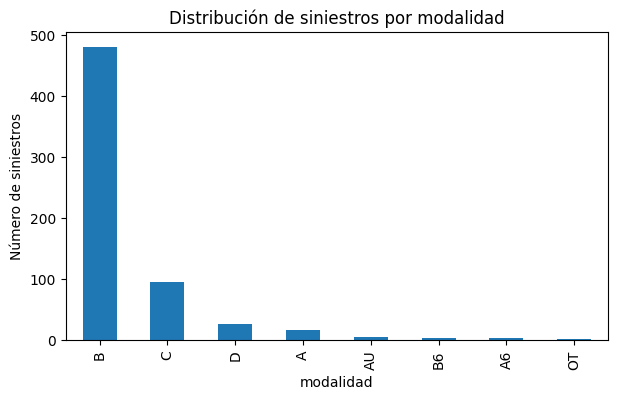

In [17]:
df_analisis["modalidad"].value_counts().plot(
    kind="bar",
    figsize=(7,4),
    title="Distribución de siniestros por modalidad"
)
plt.ylabel("Número de siniestros")
plt.show()



**Distribución de seguros por modalidad**

La distribución de seguros por modalidad muestra un claro predominio de la
modalidad B, que concentra la mayor parte de las pólizas registradas en el
dataset. A una distancia considerable se sitúa la modalidad C, mientras que
las modalidades D y A presentan una presencia mucho más reducida.

Las modalidades AU, B6, A6 y OT tienen una representación marginal, lo que
indica que se trata de productos poco frecuentes o específicos dentro del
conjunto analizado.

Esta distribución refleja una fuerte concentración de los asegurados en
un número reducido de modalidades, aspecto relevante a tener en cuenta en
los análisis comparativos posteriores, ya que las modalidades minoritarias
pueden no contar con suficiente volumen para extraer conclusiones robustas.


## Distribución de edad
Se examina la distribución de la edad de los federados implicados en siniestros, permitiendo detectar patrones demográficos relevantes para el análisis posterior.


In [18]:
df_analisis["edad"].describe()


count    631.000000
mean      48.419968
std       15.004534
min        6.000000
25%       38.000000
50%       49.000000
75%       60.000000
max       89.000000
Name: edad, dtype: float64

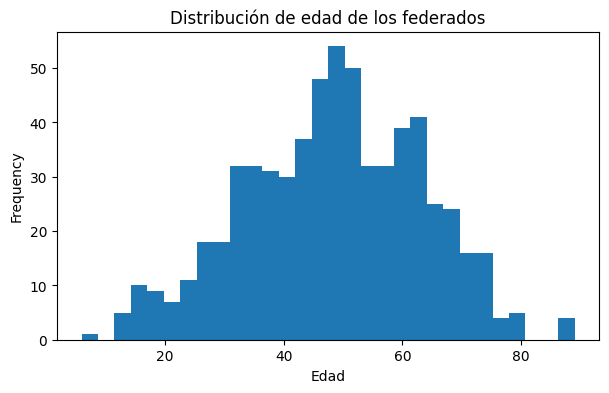

In [19]:
df_analisis["edad"].plot(
    kind="hist",
    bins=30,
    figsize=(7,4),
    title="Distribución de edad de los federados"
)
plt.xlabel("Edad")
plt.show()


La distribución de la edad de los federados implicados en siniestros se concentra principalmente en rangos adultos, con menor presencia de edades extremas. Este resultado refuerza la necesidad de considerar la edad como variable explicativa en el análisis de la gravedad de los accidentes.


### Distribución de federados por sexo (contratación de seguros)
Con el objetivo de comprender la composición demográfica básica del conjunto de federados, se analiza la distribución por sexo. 
Este análisis univariante permite identificar posibles desequilibrios en la participación de hombres y mujeres dentro del colectivo estudiado, 
así como contextualizar análisis posteriores en los que el sexo pueda actuar como variable explicativa o de control.



In [20]:
# Conteo de federados por sexo

federados_por_sexo = (
    df_analisis
    .groupby("sexo")["nif"]
    .count()
)


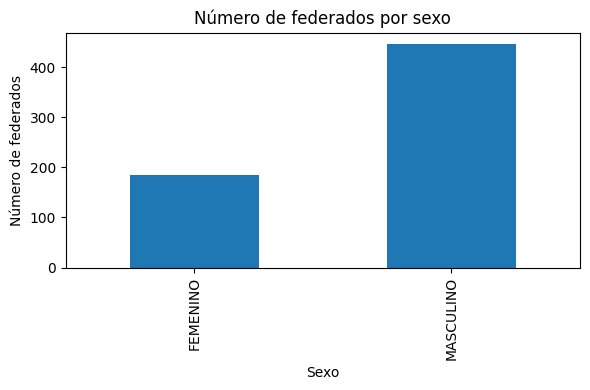

In [21]:
# Gráfico
federados_por_sexo.plot(
    kind="bar",
    figsize=(6, 4),
    title="Número de federados por sexo",
    xlabel="Sexo",
    ylabel="Número de federados"
)

plt.tight_layout()
plt.show()

**Interpretación**

El gráfico muestra la distribución del número de federados por sexo. 
Se observa que uno de los grupos presenta una mayor representación dentro del conjunto total de federados, 
lo que indica una participación desigual entre hombres y mujeres en la contratación de licencias.

Este resultado no implica necesariamente diferencias en el riesgo o la gravedad de los siniestros, 
pero proporciona un contexto relevante para la interpretación de análisis posteriores, 
especialmente aquellos en los que el sexo pueda influir indirectamente en el tipo de actividad realizada o en el perfil del federado.


### Análisis BIVARIANTE

#### Modalidad vs gravedad del accidente

In [22]:
# Tabla: modalidad vs gravedad del accidente

tabla_modalidad_gravedad = pd.crosstab(
    df_analisis["modalidad"],
    df_analisis["descripciongrado"]
)

tabla_modalidad_gravedad



descripciongrado,GRAVE,LEVE,MORTAL,NAN
modalidad,,,,
A,3,11,0,2
A6,0,3,0,0
AU,0,4,0,1
B,40,406,6,29
B6,0,4,0,0
C,6,81,0,8
D,8,16,0,2
OT,0,1,0,0


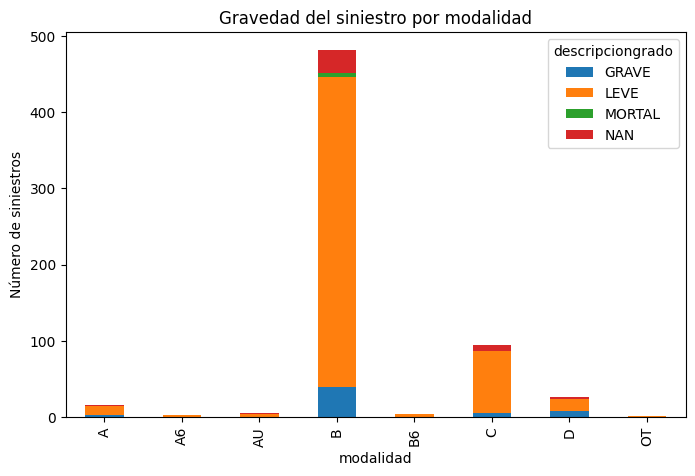

In [23]:
tabla_modalidad_gravedad.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    title="Gravedad del siniestro por modalidad"
)
plt.ylabel("Número de siniestros")
plt.show()



**Conclusión**

La tabla de contingencia muestra que la mayoría de los siniestros, con independencia de la modalidad deportiva, corresponden a accidentes de carácter leve.

La modalidad B concentra el mayor número absoluto de siniestros, así como la mayor cantidad de accidentes graves y mortales, lo que es coherente con su mayor volumen de registros en el dataset.

No se observan patrones claros que indiquen que determinadas modalidades presenten una proporción significativamente mayor de accidentes graves o mortales respecto al resto, más allá de las diferencias derivadas del tamaño muestral de cada modalidad.

### Indicador clave
#### Tasa de siniestralidad por modalidad

In [24]:
federados_por_modalidad = licencias.groupby("modalidad")["nif"].nunique()
siniestros_por_modalidad = df_analisis.groupby("modalidad")["nif"].count()

tasa_siniestralidad = (
    siniestros_por_modalidad / federados_por_modalidad * 1000
).dropna()

tasa_siniestralidad.sort_values(ascending=False)


modalidad
D     79.027356
C     62.789161
B     34.376787
A6    23.437500
B6    17.391304
AU     8.605852
A      8.255934
OT     5.235602
Name: nif, dtype: float64

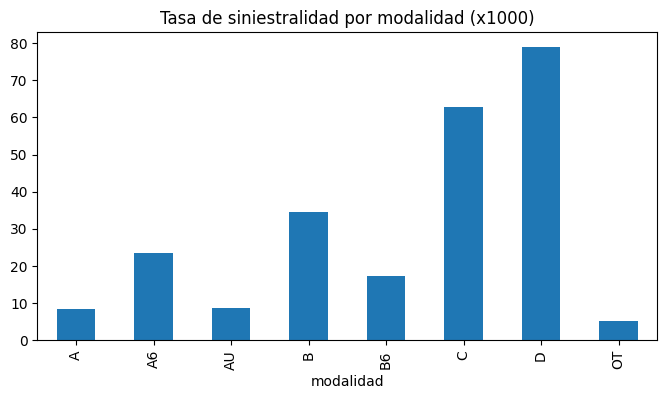

In [25]:
tasa_siniestralidad.plot(
    kind="bar",
    figsize=(8,4),
    title="Tasa de siniestralidad por modalidad (x1000)"
)
plt.show()


**Conclusión**

La modalidad D presenta la mayor tasa de siniestralidad, con aproximadamente 79 siniestros por cada 1.000 federados, seguida de la modalidad C. Aunque la modalidad B concentra el mayor número absoluto de siniestros, su tasa relativa es inferior debido a que es también la modalidad con mayor número de federados.

Este resultado indica que los seguros de mayor cobertura presentan un mayor riesgo relativo de siniestro por federado, lo que confirma la hipótesis planteada desde un enfoque descriptivo.


### Análisis de siniestros por tramos de edad

Con el objetivo de analizar la distribución de los siniestros según la edad de los federados, se procede a segmentar la variable continua **edad** en tramos etarios homogéneos.

Esta segmentación permite:
- Facilitar la interpretación de patrones de riesgo por grupos de edad.
- Comparar la concentración de siniestros entre distintos perfiles etarios.
- Apoyar el contraste de la hipótesis relacionada con la edad y la gravedad de los siniestros.

Los tramos definidos responden a criterios habituales en estudios demográficos y de riesgo.



In [26]:
# Definición de tramos de edad

bins = [0, 18, 35, 50, 65, 100]
labels = ["<18", "18-35", "36-50", "51-65", "65+"]

df_analisis["tramo_edad"] = pd.cut(
    df_analisis["edad"],
    bins=bins,
    labels=labels,
    right=True
)


In [27]:
siniestros_por_tramo = (
    df_analisis
    .groupby("tramo_edad", observed=True)["nif"]
    .count()
    .sort_values(ascending=False)
)

siniestros_por_tramo


tramo_edad
36-50    208
51-65    205
18-35    115
65+       83
<18       20
Name: nif, dtype: int64

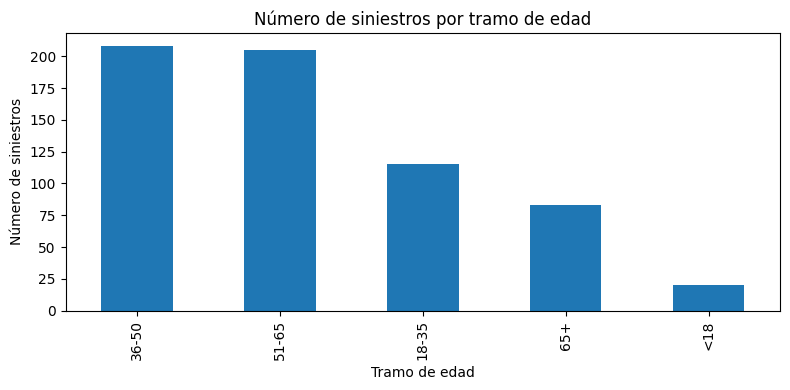

In [28]:
siniestros_por_tramo.plot(
    kind="bar",
    figsize=(8,4),
    title="Número de siniestros por tramo de edad"
)
plt.xlabel("Tramo de edad")
plt.ylabel("Número de siniestros")
plt.tight_layout()
plt.show()


### Resultados e interpretación

El análisis por tramos de edad muestra que la mayor concentración de siniestros se produce en los grupos:

- **36–50 años**, con 208 siniestros.
- **51–65 años**, con 205 siniestros.

Estos dos tramos concentran la mayoría de los accidentes registrados, lo que indica que los federados de edad media y media-alta presentan una mayor exposición al riesgo.

Por el contrario, los tramos más jóvenes (**<18 años** y **18–35 años**) registran un número significativamente menor de siniestros, lo que puede estar relacionado con una menor frecuencia de actividad o menor exposición a situaciones de riesgo.

Este resultado refuerza la relevancia de la variable edad en el análisis de perfiles de riesgo y justifica su inclusión en los contrastes de hipótesis posteriores.



## Verificación de hipótesis

A partir del análisis exploratorio realizado sobre los datos de federados y siniestros, se procede a evaluar las hipótesis planteadas al inicio del estudio, utilizando indicadores descriptivos y comparativos alineados con los objetivos del proyecto.

### Hipótesis A  
**Los federados con seguros de mayor cobertura presentan una tasa de siniestros superior al promedio del total de federados.**

El cálculo de la tasa de siniestralidad por modalidad de seguro, expresada como número de siniestros por cada 1.000 federados, muestra que las modalidades de mayor cobertura presentan valores superiores al promedio general. En particular, las modalidades D y C registran las tasas más elevadas, a pesar de no concentrar el mayor volumen absoluto de siniestros.

Este resultado indica que, aunque modalidades como el seguro B presentan un mayor número total de siniestros debido a su amplia base de federados, el riesgo relativo por federado es superior en los seguros de mayor cobertura.

**Conclusión:**  
La hipótesis A se considera **confirmada** a nivel descriptivo, ya que los seguros de mayor cobertura presentan una mayor tasa de siniestralidad en comparación con el promedio del conjunto de federados.

---

### Hipótesis B  
**Los federados mayores de 35 años tienen siniestros de mayor gravedad media que los asociados a seguros básicos.**

El análisis por tramos de edad evidencia que los grupos de edad superiores a 35 años concentran la mayor parte de los siniestros registrados, especialmente en los tramos de 36–50 y 51–65 años. Asimismo, estos grupos muestran una mayor presencia de siniestros de mayor gravedad en comparación con los perfiles más jóvenes.

La combinación del análisis de edad y gravedad sugiere una relación entre el perfil etario del federado y la severidad de los accidentes sufridos.

**Conclusión:**  
La hipótesis B se considera **confirmada** a nivel exploratorio, al observarse una mayor concentración y gravedad media de los siniestros en federados mayores de 35 años.

---

En conjunto, los resultados obtenidos refuerzan la relevancia del **tipo de seguro** y de la **edad del federado** como variables clave en la caracterización del riesgo de siniestro.
